In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
os.listdir('/content/drive/MyDrive/Data')

['crypto']

In [18]:
import pandas as pd


df = pd.read_csv('/content/drive/MyDrive/Data/crypto/expanded_dataset.csv')
#df= pd.read_csv('/content/drive/MyDrive/data/expanded_dataset .csv')
#df = pd.read_csv('/content/drive/MyDrive/data/expanded_transaction_dataset (2).csv') #contains 48 features

#handling missing values

df.isnull().sum() #checking missing values #count of missing values in each feature which is denoted as true
df.fillna(df.median(), inplace=True) #filling missing values with median
print(df.shape)
print(df.head())
print(df.info())
print(df['FLAG'].value_counts())


(19841, 48)
   Unnamed: 0  Index  FLAG  Avg min between sent tnx  \
0           0      1     0                    844.26   
1           1      2     0                  12709.07   
2           2      3     0                 246194.54   
3           3      4     0                  10219.60   
4           4      5     0                     36.61   

   Avg min between received tnx  Time Diff between first and last (Mins)  \
0                       1093.71                                704785.63   
1                       2958.44                               1218216.73   
2                       2434.02                                516729.30   
3                      15785.09                                397555.90   
4                      10707.77                                382472.42   

   Sent tnx  Received Tnx  Number of Created Contracts  \
0       721            89                            0   
1        94             8                            0   
2         2         

df has the entire dataset.

df.shape will return no of rows and coloumns.

df.head will show the first 5 dataset..to understand how the data looks.

df.info will give column names,number of non null values,data types.

df[value].value_counts gives the count of values which is in the column FLAG.




In [19]:
# Features = all columns except 'flag'
df = df.drop(columns=['Unnamed: 0',"Index"])
X = df.drop(columns=['FLAG'])

# Target = 'flag'
y = df['FLAG']

#

1.df.drop drops the flag column , we drop it bcz it is our output

2.y stores the target output ,this is what the model predicts




In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scikit-ml model

sklearn.model_selection is a module in scikit used for splitting data and texting models

train_test_split is used to split the dataset into training and testing set

x (inputs),y(ouput), test_size=0.2 means testing data is 20%

random state controls the shuffling of data,here it is 42 so it always gives the samesplit everytime

stratify =y , will make sure that data divided properly{equal proportion of subgroup)

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

ensemble(combine multiple models to improve accuracy) is a module that contains ensemble algorithms

random forest is one of the ensembling algorithm

random forest classifier classifies legimitate or fraud


rf contains the random forest model

n_estimators=100 (no. of decision trees)

class_weight="balanced" makes the model to give more priority to fraudelent bcz they are less compared to normal wallet.

fit() means training the model.

the model generate multiple decision trees while training.

so thw model will learn the rule for detecting the fraud wallet by itself(learns pattern for finding fraud walletz).

In [22]:
# Predict FLAG for test data
y_pred = rf.predict(X_test)

# Optional: first 20 predictions
print("Predictions (first 20):", y_pred[:20])

Predictions (first 20): [1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 1 0 0 0 1]


rf contains the trained randomforest model

rf.predict(x_test)
the input features of test are sent to trained model , the decision trees checks the values and gives prediction

the rf combines the final result and gives the result

0-legimitate
1-fraud

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Classification report (precision, recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9954648526077098

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3102
           1       1.00      0.98      0.99       867

    accuracy                           1.00      3969
   macro avg       1.00      0.99      0.99      3969
weighted avg       1.00      1.00      1.00      3969


Confusion Matrix:
 [[3099    3]
 [  15  852]]


# ACCURACY

Accuracy = Correct Predictions / Total Predictions

y_test have real data

y_pred have the predicted data

comparing both results gives the accuarcy

#CLASSIFICATION REPORT

performance metrics

Precision = True Fraud / Predicted Fraud(how many predicted frauds are actually fraud)

Recall = True Fraud / Actual Fraud (how many actual frauds the model predicted)

F1 = 2 × (Precision × Recall) / (Precision + Recall) - balance btw precision and recall

here 1.00( 100% accurate)

support gives the no of transaction for each class
0-legimitate (1533)
1-fraud(436)

##confusion matrix

|                   | Predicted Normal | Predicted Fraud |
| ----------------- | ---------------- | --------------- |
| **Actual Normal** | True Negative    |* False Positive*  |
| **Actual Fraud**  |* False Negative*   | True Positive   |

TN-actual = predicted = normal then correct prediction

FP-actual=normal,predicted=fraud then incorrect prediction

FN-actual=fraud ,predicted=normal, incorrect(dangerous)

TP-actual=fraud,predicted=fraud then correct prediction

Confusion Matrix:

 [[1533    0]

 [   0  436]]


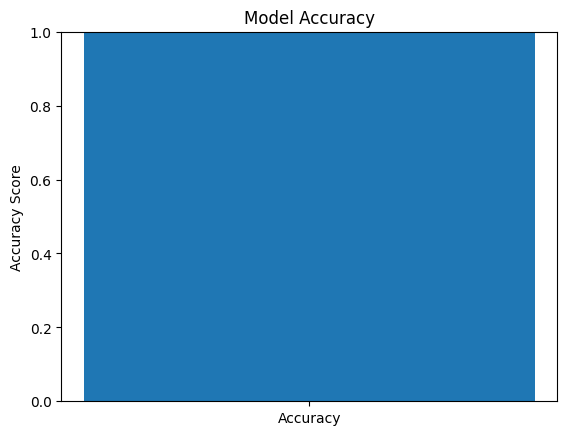

In [24]:
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)

plt.bar(["Accuracy"], [accuracy])
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy Score")
plt.show()

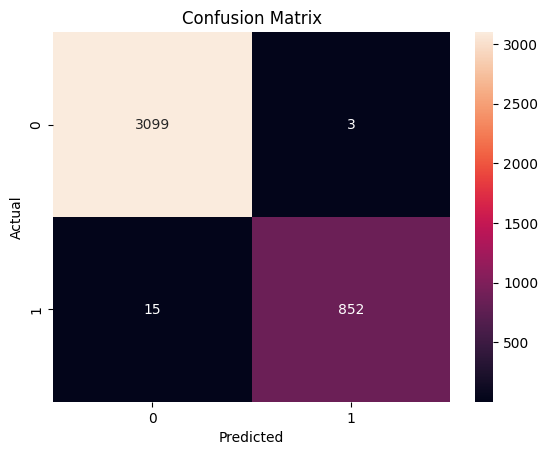

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")#draws a color-coded matrix.#annot is used for numbering inside the matrix #fmt-display value as integers
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

there is no 0 incorrection because the model classifying all the transactions correctly.

this is small and clean dataset

the dataset is too small so it memorize

Highly Predictive Features: The dataset may have strong indicators of fraud, making it easy for the model to classify correctly.


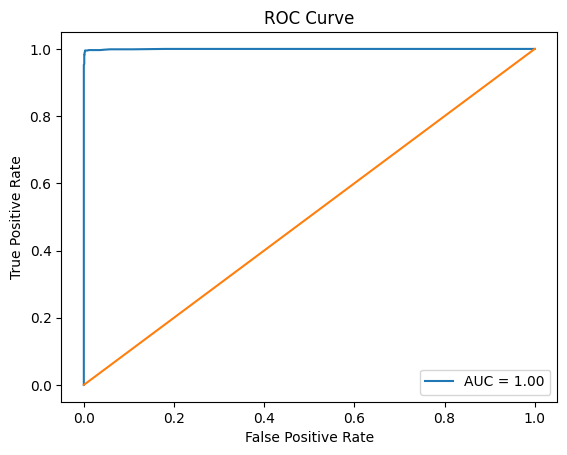

In [26]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

the ROC curve is used to evaluate the classification performance of the fraud detection model by plotting the true positive rate against the false positive rate at different threshold values. The AUC score indicates how well the model distinguishes fraudulent and legitimate transactions.

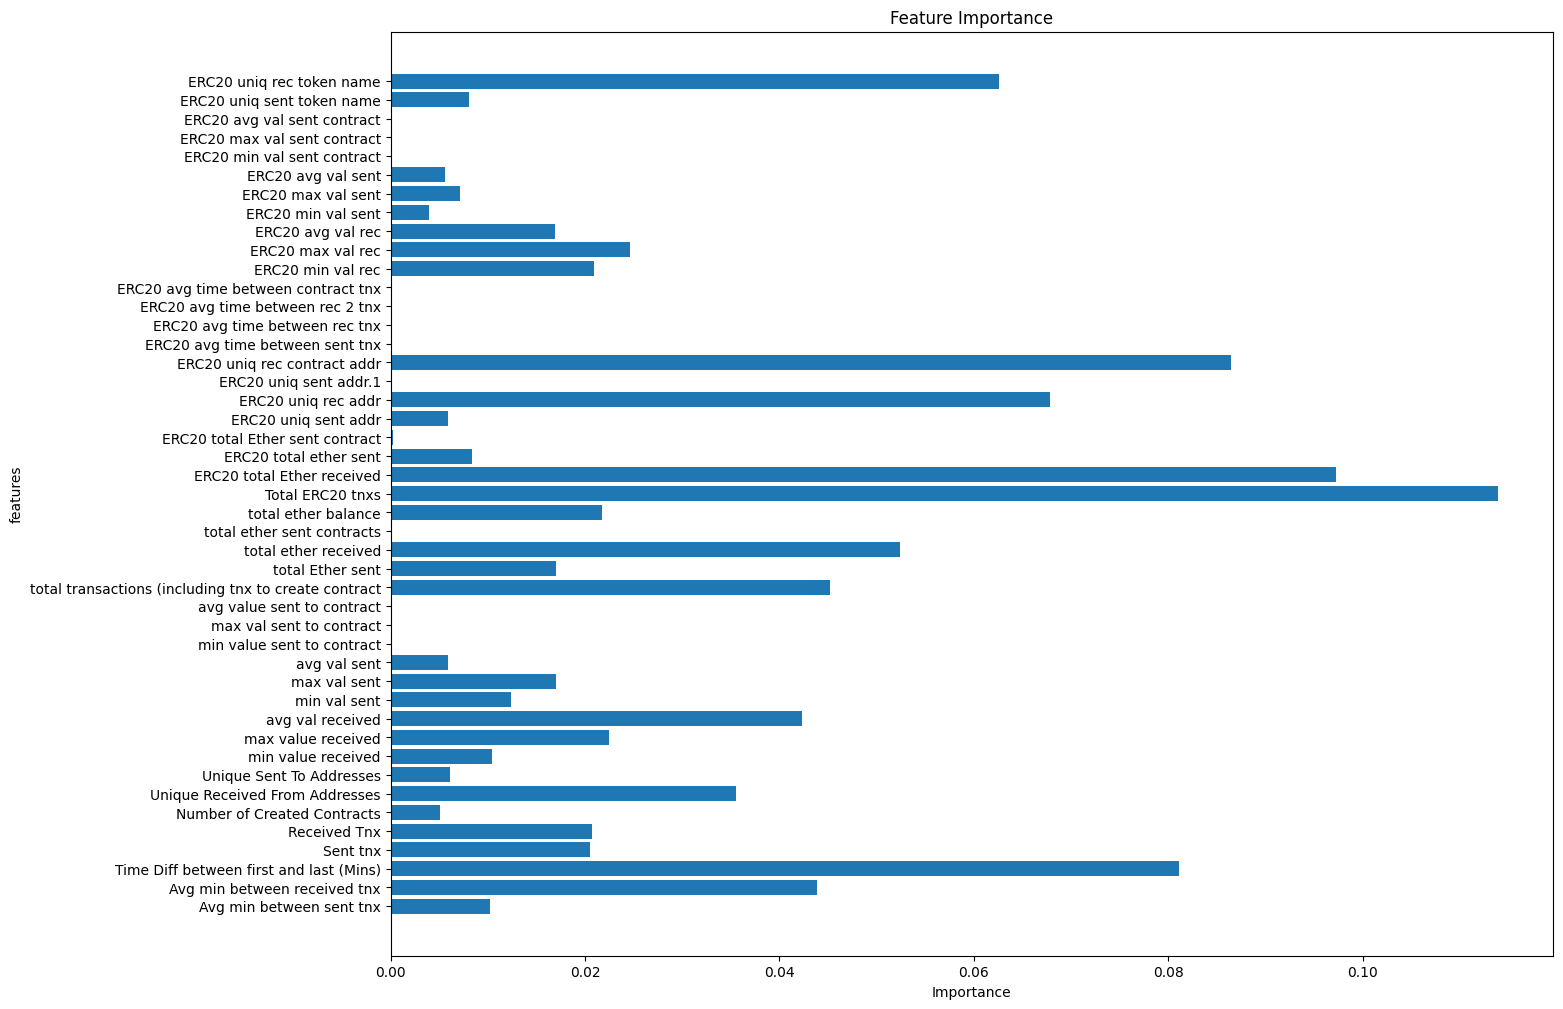

In [27]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_

# Plot horizontal bar chart
plt.figure(figsize=(15,12))
plt.barh(X_train.columns, importances)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("features")
plt.show()



#GRAPH PLOTTING

importances = rf.feature_importances_

this gives the important scores of each feature

higer value - more influence on prediction

lower value-less important

these values are automatically calculated by randomforest model

barh means horizontal bars

In [28]:
import joblib

# Save the trained model
joblib.dump(rf, "ethereum_fraud_rf_model.pkl")
print("Model saved successfully as ethereum_fraud_rf_model.pkl")

Model saved successfully as ethereum_fraud_rf_model.pkl


# JOLIB

Joblib is a Python library used to save and load machine learning models.

It stores models in a binary file format.

uses:

Avoid retraining the model every time

Load the trained model quickly

Use the model in real applications

In [29]:
import os

# List files in the current directory (where the model was saved)
print(os.listdir('/content/'))

['.config', 'drive', 'ethereum_fraud_rf_model.pkl', 'sample_data']


In [30]:
import joblib

# Load the saved model
loaded_rf_model = joblib.load('/content/ethereum_fraud_rf_model.pkl')

print("Model loaded successfully!")
# You can now use loaded_rf_model for predictions or further analysis, for example:
# y_pred_loaded = loaded_rf_model.predict(X_test)
# print("Predictions with loaded model (first 5):", y_pred_loaded[:5])

Model loaded successfully!


In [31]:
import time

start = time.time()

# Example: all your steps
# 1. Load data
# 2. Preprocess
# 3. Train Random Forest
# 4. Predict

end = time.time()
print("Total runtime:", end - start, "seconds")

Total runtime: 3.266334533691406e-05 seconds


In [32]:
start_train = time.time()         # Start timer
rf.fit(X_train, y_train)          # Train model
end_train = time.time()           # End timer

training_time = end_train - start_train
print("Training Time: {:.4f} seconds".format(training_time))

Training Time: 2.9328 seconds


In [33]:
start_test = time.time()          # Start timer
y_pred = rf.predict(X_test)       # Make predictions
end_test = time.time()            # End timer

testing_time = end_test - start_test
print("Testing / Prediction Time: {:.4f} seconds".format(testing_time))

Testing / Prediction Time: 0.0628 seconds


In [34]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Load your dataset
data = pd.read_csv('/content/drive/MyDrive/Data/crypto/redownload.csv')
X = data.drop('FLAG', axis=1)   # features
y = data['FLAG']                # labels

# Initialize Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation
scores = cross_val_score(rf, X, y, cv=skf, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [1. 1. 1. 1. 1.]
Average accuracy: 1.0
